kspace : (36, 640, 372) complex64
rss    : (36, 320, 320) float32


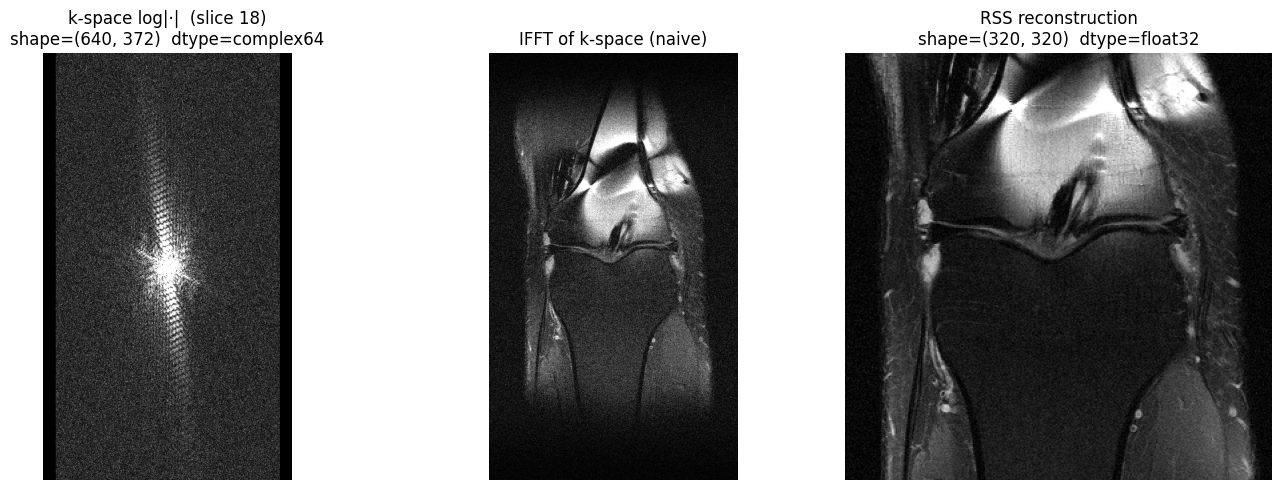

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

FILE = "../file1000001.h5"

with h5py.File(FILE, "r") as f:
    kspace = f["kspace"][:]               # (36, 640, 372) complex64
    rss    = f["reconstruction_rss"][:]   # (36, 320, 320) float32

print("kspace :", kspace.shape, kspace.dtype)
print("rss    :", rss.shape,    rss.dtype)

sl  = kspace.shape[0] // 2
ks  = kspace[sl]   # (640, 372) complex64
img = rss[sl]      # (320, 320) float32

naive = np.abs(np.fft.ifftshift(np.fft.ifft2(np.fft.ifftshift(ks))))

def norm(x, lo=1, hi=99):
    """Clip to percentile range then scale to [0, 1]."""
    a, b = np.percentile(x, lo), np.percentile(x, hi)
    return np.clip((x - a) / (b - a + 1e-8), 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(norm(np.log1p(np.abs(ks))), cmap="gray")
axes[0].set_title(f"k-space log|·|  (slice {sl})\nshape={ks.shape}  dtype={ks.dtype}")
axes[0].axis("off")

axes[1].imshow(norm(naive), cmap="gray")
axes[1].set_title("IFFT of k-space (naive)")
axes[1].axis("off")

axes[2].imshow(norm(img), cmap="gray")
axes[2].set_title(f"RSS reconstruction\nshape={img.shape}  dtype={img.dtype}")
axes[2].axis("off")

plt.tight_layout()
plt.show()


In [47]:
h, w = ks.shape  # 640, 372
center = w // 2  # 320

ks_cropped = ks[:, center - 160 : center + 160]

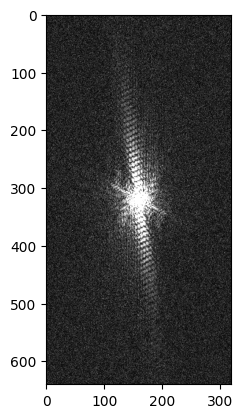

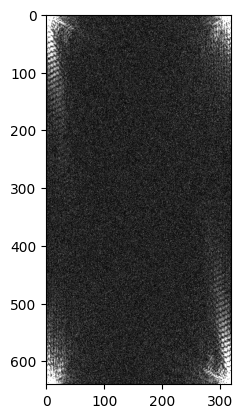

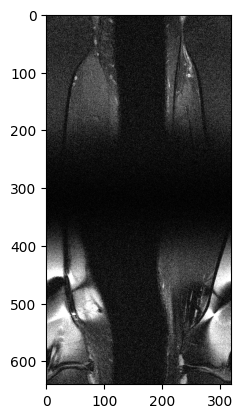

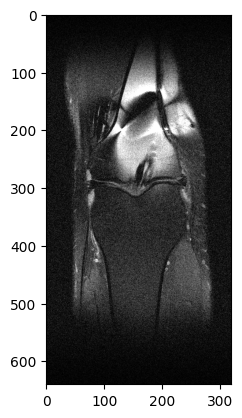

In [48]:
Raw = ks_cropped
shifted = np.fft.ifftshift(Raw)
ifft = np.fft.ifft2(shifted)
image = np.fft.fftshift(ifft)

plt.imshow(norm(np.log1p(np.abs(Raw))), cmap="gray")
plt.show()

plt.imshow(norm(np.log1p(np.abs(shifted))), cmap="gray")
plt.show()

plt.imshow(norm(np.log1p(np.abs(ifft))), cmap="gray")
plt.show()

plt.imshow(norm(np.log1p(np.abs(image))), cmap="gray")  
plt.show()


attrs['max']  = 0.0009
attrs['norm'] = 0.0597


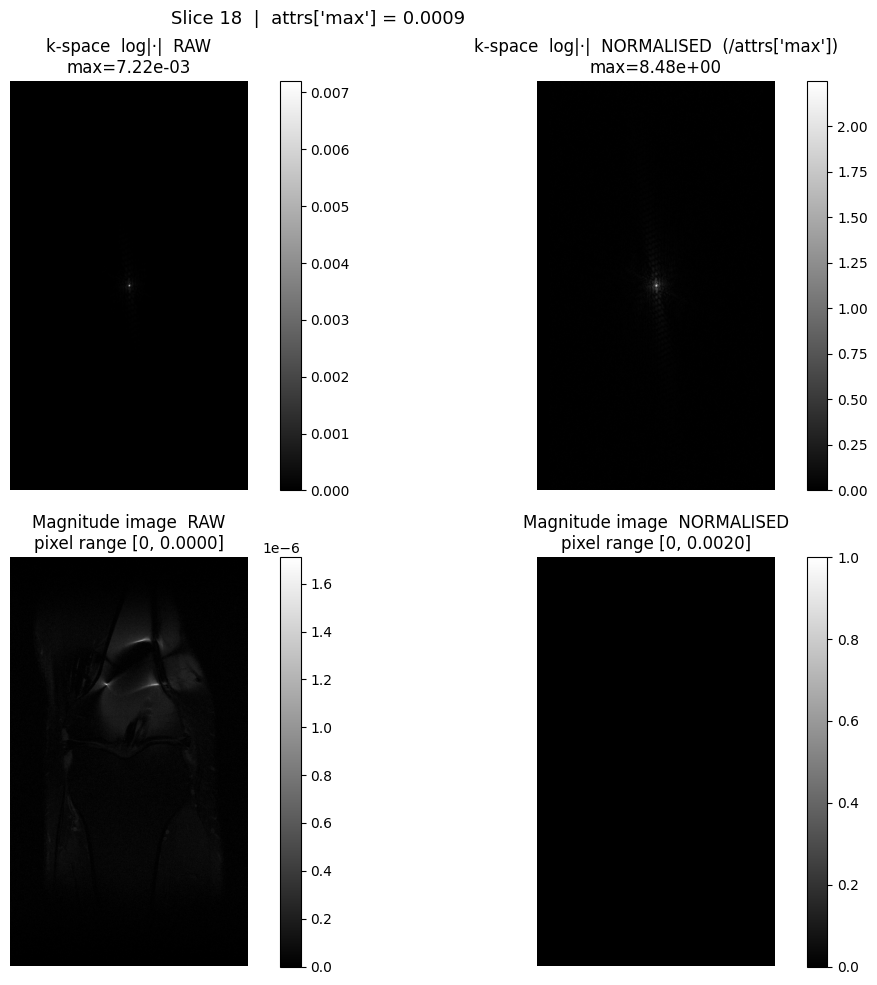

In [50]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

FILE = "../file1000001.h5"

with h5py.File(FILE, "r") as f:
    kspace = f["kspace"][:]
    rss    = f["reconstruction_rss"][:]
    max_val  = f.attrs["max"]   # fastMRI normalisation scalar
    norm_val = f.attrs["norm"]  # k-space norm (less commonly used)

print(f"attrs['max']  = {max_val:.4f}")
print(f"attrs['norm'] = {norm_val:.4f}")

sl = kspace.shape[0] // 2
ks = kspace[sl]          # (640, 372) complex64

# ── reconstructions ──────────────────────────────────────────────────────────
naive_img      = np.abs(np.fft.ifftshift(np.fft.ifft2(np.fft.ifftshift(ks))))
naive_img_norm = naive_img / max_val

ks_norm        = ks / max_val

# ── plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# row 0 — k-space log magnitude
im00 = axes[0, 0].imshow(np.log1p(np.abs(ks)),      cmap="gray")
im01 = axes[0, 1].imshow(np.log1p(np.abs(ks_norm)), cmap="gray")
axes[0, 0].set_title(f"k-space  log|·|  RAW\nmax={np.abs(ks).max():.2e}")
axes[0, 1].set_title(f"k-space  log|·|  NORMALISED  (/attrs['max'])\nmax={np.abs(ks_norm).max():.2e}")
plt.colorbar(im00, ax=axes[0, 0])
plt.colorbar(im01, ax=axes[0, 1])

# row 1 — magnitude image
im10 = axes[1, 0].imshow(naive_img,      cmap="gray", vmin=0, vmax=naive_img.max())
im11 = axes[1, 1].imshow(naive_img_norm, cmap="gray", vmin=0, vmax=1.0)
axes[1, 0].set_title(f"Magnitude image  RAW\npixel range [0, {naive_img.max():.4f}]")
axes[1, 1].set_title(f"Magnitude image  NORMALISED\npixel range [0, {naive_img_norm.max():.4f}]")
plt.colorbar(im10, ax=axes[1, 0])
plt.colorbar(im11, ax=axes[1, 1])

for ax in axes.flat:
    ax.axis("off")

plt.suptitle(f"Slice {sl}  |  attrs['max'] = {max_val:.4f}", fontsize=13)
plt.tight_layout()
plt.show()

In [51]:
with h5py.File(FILE, "r") as f:
    print("=== datasets ===")
    for key in f.keys():
        obj = f[key]
        print(f"  {key}: shape={obj.shape}, dtype={obj.dtype}")

    print("\n=== attributes ===")
    for key, val in f.attrs.items():
        print(f"  {key}: {val}")

=== datasets ===
  ismrmrd_header: shape=(), dtype=object
  kspace: shape=(36, 640, 372), dtype=complex64
  reconstruction_esc: shape=(36, 320, 320), dtype=float32
  reconstruction_rss: shape=(36, 320, 320), dtype=float32

=== attributes ===
  acquisition: CORPDFS_FBK
  max: 0.000851878253624366
  norm: 0.0596983310320022
  patient_id: 0beb8905d9b7fad304389b9d4263c57d5b069257ea0fdc5bf7f2675608a47406
